In [ ]:
import pandas as pd
df = pd.read_csv("/content/GlobalTemperatures.csv")

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(3192, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), object(1)
memory usage: 224.6+ KB
None
dt                               

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
%matplotlib inline
sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("GlobalTemperatures.csv")  # Loads the dataset into a Pandas DataFrame
df['dt'] = pd.to_datetime(df['dt'])  # Converts 'dt' column to datetime format
df = df.set_index('dt')  # Sets 'dt' as the index for time-series operations

# Drop uncertainty columns to focus on core metrics
df = df.drop(columns=[col for col in df.columns if 'Uncertainty' in col])

# Convert LandAverageTemperature from °C to °F, preserving nulls
df['LandAverageTemperature_F'] = df['LandAverageTemperature'].apply(
    lambda x: (x * 1.8) + 32 if pd.notnull(x) else x
)

In [ ]:
df['year'] = df.index.year
df['month'] = df.index.month
df_yearly = df.resample('Y').mean()


/tmp/ipython-input-3050249474.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df.resample('Y').mean()


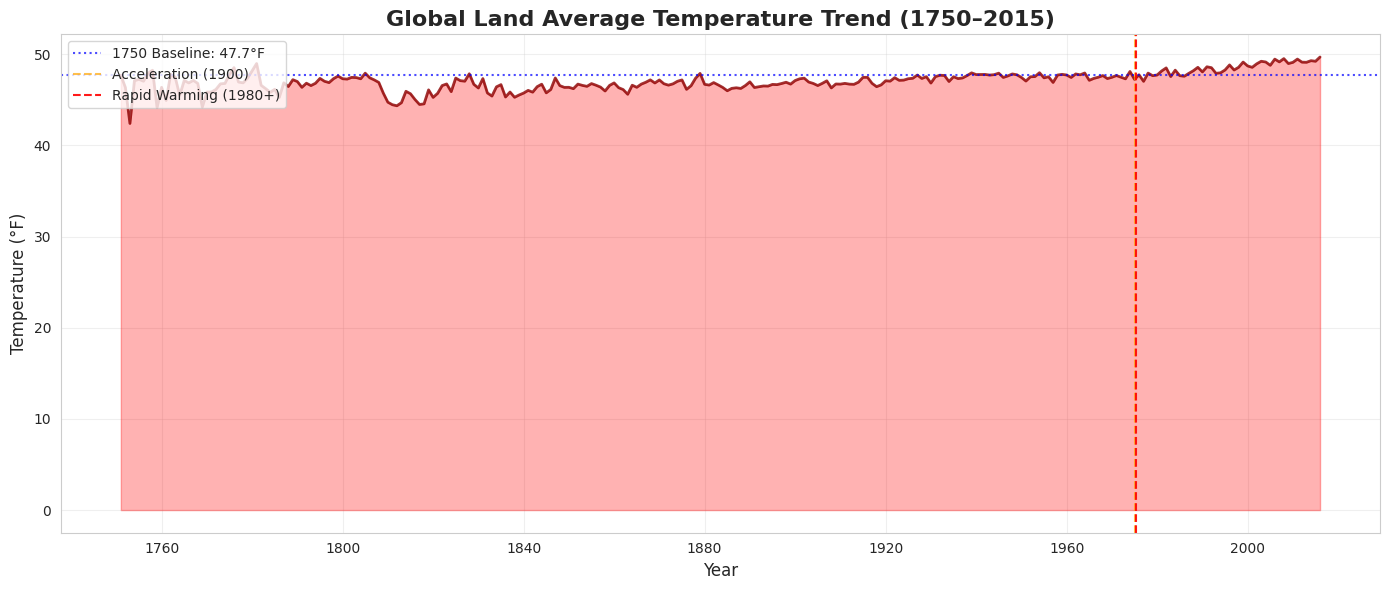

1750 Temp: 47.7°F | 2015 Temp: 49.7°F | Total Rise: 2.00°F


In [ ]:
import matplotlib.pyplot as plt

# Use the df_yearly from 5.3 and drop NaNs for clean plot
temp_trend = df_yearly['LandAverageTemperature_F'].dropna()

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(temp_trend.index, temp_trend.values, linewidth=2, color='darkred', alpha=0.8)
plt.fill_between(temp_trend.index, temp_trend.values, alpha=0.3, color='red')

# Annotations for key periods (makes it academic-looking)
plt.axhline(y=temp_trend.iloc[0], color='blue', linestyle=':', alpha=0.7, label=f'1750 Baseline: {temp_trend.iloc[0]:.1f}°F')
plt.axvline(x=1900, color='orange', linestyle='--', alpha=0.7, label='Acceleration (1900)')
plt.axvline(x=1980, color='red', linestyle='--', alpha=0.9, label='Rapid Warming (1980+)')

plt.title('Global Land Average Temperature Trend (1750–2015)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°F)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print stats for report caption
print(f"1750 Temp: {temp_trend.iloc[0]:.1f}°F | 2015 Temp: {temp_trend.iloc[-1]:.1f}°F | Total Rise: {temp_trend.iloc[-1] - temp_trend.iloc[0]:.2f}°F")

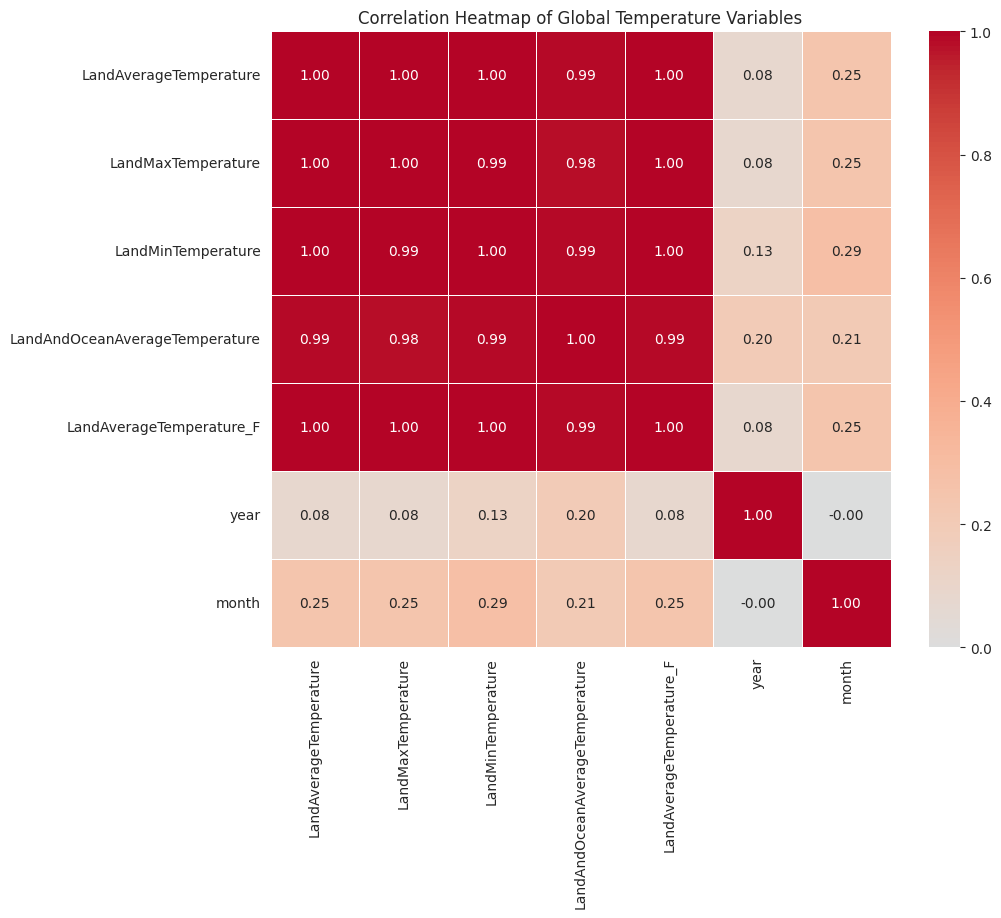

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Global Temperature Variables")
plt.show()


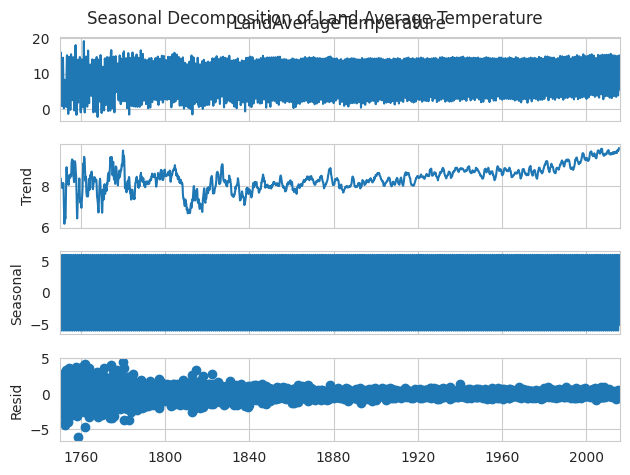

In [ ]:
temp_series = df['LandAverageTemperature'].interpolate()
decomposition = seasonal_decompose(temp_series, model='additive', period=12)
decomposition.plot()
plt.suptitle("Seasonal Decomposition of Land Average Temperature")
plt.show()
